In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore') 
sns.set_theme(style="whitegrid")

In [21]:
# Đọc dữ liệu
df = pd.read_csv('D:\loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

df.shape
##df.head()


(4269, 13)

In [23]:
# Khởi tạo các bộ mã hóa riêng biệt để sau này còn dùng lại cho việc dự đoán
le_education = LabelEncoder()
le_self_employed = LabelEncoder()
le_status = LabelEncoder()

# Tiến hành mã hóa
df['education'] = le_education.fit_transform(df['education'])
df['self_employed'] = le_self_employed.fit_transform(df['self_employed'])
df['loan_status'] = le_status.fit_transform(df['loan_status']) # 0: Approved, 1: Rejected

print("Đã mã hóa các cột phân loại thành số!")

Đã mã hóa các cột phân loại thành số!


## so sánh hai mô hình random forest với decision tree

In [24]:
print("KHẢO SÁT CÁC MÔ HÌNH TRÊN DỮ LIỆU CHƯA TỐI ƯU")
X_base = df.drop(columns=['loan_id', 'loan_status'])
y_base = df['loan_status']

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.2, random_state=42, stratify=y_base)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_base, y_train_base)
    y_pred = model.predict(X_test_base)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_base, y_pred),
        "Precision": precision_score(y_test_base, y_pred),
        "Recall": recall_score(y_test_base, y_pred),
        "F1-Score": f1_score(y_test_base, y_pred)
    })

df_results = pd.DataFrame(results)
display(df_results.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], color='lightgreen', axis=0))
print("=> KẾT LUẬN: Random Forest vượt trội hơn. Ta sẽ chọn thuật toán này làm core cho các bước tiếp theo!")

KHẢO SÁT CÁC MÔ HÌNH TRÊN DỮ LIỆU CHƯA TỐI ƯU


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.971897,0.974603,0.950464,0.962382
1,Random Forest,0.983607,0.990476,0.965944,0.978056


=> KẾT LUẬN: Random Forest vượt trội hơn. Ta sẽ chọn thuật toán này làm core cho các bước tiếp theo!


In [25]:
print("TẠO THÊM ĐẶC TRƯNG TÀI CHÍNH MỚI")

df['loan_to_income_ratio'] = df['loan_amount'] / df['income_annum']
df['total_assets_value'] = (df['residential_assets_value'] + 
                            df['commercial_assets_value'] + 
                            df['luxury_assets_value'] + 
                            df['bank_asset_value'])
df['loan_to_asset_ratio'] = df['loan_amount'] / (df['total_assets_value'] + 1)

df.shape

TẠO THÊM ĐẶC TRƯNG TÀI CHÍNH MỚI


(4269, 16)

## chia tập dữ liệu và  chuẩn hóa 

In [26]:

# Chia lại tập Train/Test vì dữ liệu df đã có thêm 3 cột mới
X_eng = df.drop(columns=['loan_id', 'loan_status'])
y_eng = df['loan_status']
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng)

scaler = StandardScaler()
# Chuẩn hóa nhưng ép ngược lại thành DataFrame để giữ lại tên các cột (phục vụ vẽ biểu đồ)
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_eng), columns=X_train_eng.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_eng), columns=X_test_eng.columns)

print("Đã chuẩn hóa (Scale) xong tập dữ liệu mới!")

Đã chuẩn hóa (Scale) xong tập dữ liệu mới!


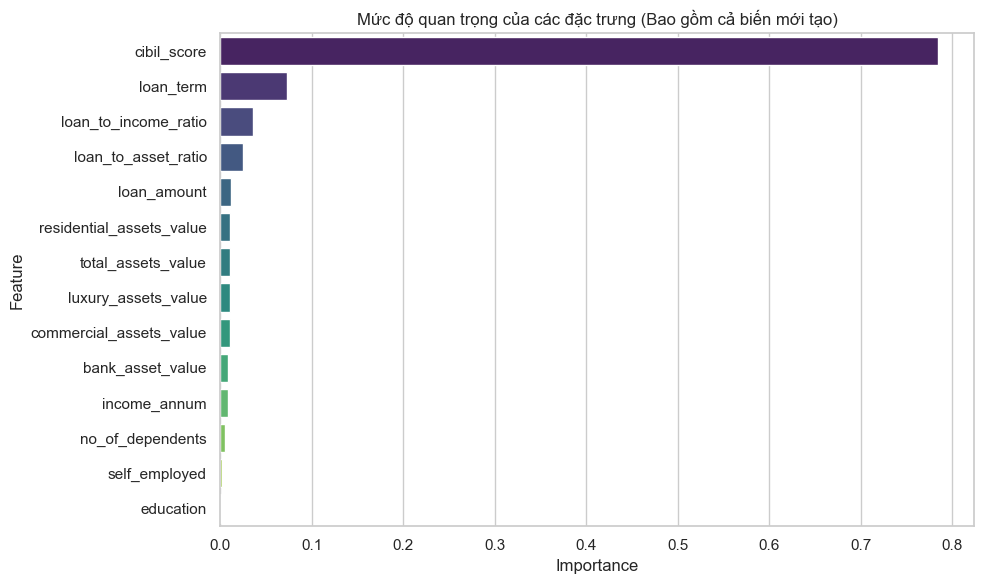

In [27]:
# Train mô hình Random Forest trên tập dữ liệu đã scale và có biến mới
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_scaled, y_train_eng)

# Lấy độ quan trọng của biến
feature_importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Mức độ quan trọng của các đặc trưng (Bao gồm cả biến mới tạo)')
plt.tight_layout()
plt.show()

In [28]:
# Loại bỏ các biến có độ quan trọng quá thấp (dưới 1%)
threshold = 0.01
important_features = feature_importance_df[feature_importance_df['Importance'] > threshold]['Feature'].tolist()

print(f"Tổng số biến ban đầu: {X_train_scaled.shape[1]}")
print(f"Số biến được giữ lại: {len(important_features)}")
print(f"Các biến bị vứt bỏ: {set(X_train_scaled.columns) - set(important_features)}")

# Tạo tập dữ liệu "Sạch & Gọn" chỉ chứa các biến quan trọng
X_train_final = X_train_scaled[important_features]
X_test_final = X_test_scaled[important_features]

Tổng số biến ban đầu: 14
Số biến được giữ lại: 9
Các biến bị vứt bỏ: {'self_employed', 'education', 'bank_asset_value', 'no_of_dependents', 'income_annum'}


In [29]:
print(" DỰ ĐOÁN CUỐI CÙNG VỚI MÔ HÌNH ĐÃ LỌC BIẾN")

final_rf = RandomForestClassifier(n_estimators=100, random_state=42)
final_rf.fit(X_train_final, y_train_eng)

y_pred_final = final_rf.predict(X_test_final)

print("\nBÁO CÁO HIỆU SUẤT ")
print(classification_report(y_test_eng, y_pred_final, target_names=['Approved', 'Rejected']))

print("Ma trận nhầm lẫn (Confusion Matrix):")
print(confusion_matrix(y_test_eng, y_pred_final))

 DỰ ĐOÁN CUỐI CÙNG VỚI MÔ HÌNH ĐÃ LỌC BIẾN

BÁO CÁO HIỆU SUẤT 
              precision    recall  f1-score   support

    Approved       1.00      1.00      1.00       531
    Rejected       1.00      1.00      1.00       323

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

Ma trận nhầm lẫn (Confusion Matrix):
[[531   0]
 [  0 323]]


In [30]:
# Lưu toàn bộ model, scaler, encoder và DANH SÁCH BIẾN đã lọc
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(final_rf, 'best_rf_model.pkl')
joblib.dump(le_education, 'le_education.pkl')
joblib.dump(le_self_employed, 'le_self_employed.pkl')
joblib.dump(le_status, 'le_status.pkl')
joblib.dump(important_features, 'important_features_list.pkl')

print("[THÀNH CÔNG] Đã lưu toàn bộ pipeline thành các file .pkl để dự đoán thực tế!")

[THÀNH CÔNG] Đã lưu toàn bộ pipeline thành các file .pkl để dự đoán thực tế!


In [31]:

print(" CHƯƠNG TRÌNH DỰ ĐOÁN TÍN DỤNG TỰ ĐỘNG ")

try:
    print("\nVui lòng nhập đầy đủ các thông tin của hồ sơ mới:")
    
    no_of_dependents = int(input("- Số người phụ thuộc (ví dụ: 2): "))
    
    education = input("- Học vấn (Graduate hoặc Not Graduate): ").strip()
    while education not in ['Graduate', 'Not Graduate']:
        print(" Lỗi: Vui lòng nhập 'Graduate' hoặc 'Not Graduate'")
        education = input("- Học vấn: ").strip()
        
    self_employed = input("- Tự kinh doanh? (Yes hoặc No): ").strip()
    while self_employed not in ['Yes', 'No']:
        print("Lỗi: Vui lòng nhập 'Yes' hoặc 'No'")
        self_employed = input("- Tự kinh doanh?: ").strip()

    income_annum = float(input("- Thu nhập hàng năm (ví dụ: 9600000): "))
    loan_amount = float(input("- Khoản vay đề xuất (ví dụ: 29900000): "))
    loan_term = int(input("- Thời hạn vay (số tháng, ví dụ: 12): "))
    cibil_score = int(input("- Điểm tín dụng CIBIL (ví dụ: 778): "))
    
    print("\n Nhập giá trị tài sản sở hữu")
    residential_assets_value = float(input("+ Giá trị BĐS nhà ở (ví dụ: 2400000): "))
    commercial_assets_value = float(input("+ Giá trị BĐS thương mại (ví dụ: 17600000): "))
    luxury_assets_value = float(input("+ Giá trị tài sản xa xỉ (ví dụ: 22700000): "))
    bank_asset_value = float(input("+ Tiền gửi ngân hàng (ví dụ: 8000000): "))

    # 1. Chuyển thành DataFrame
    df_new = pd.DataFrame([{
        'no_of_dependents': no_of_dependents,
        'education': education,
        'self_employed': self_employed,
        'income_annum': income_annum,
        'loan_amount': loan_amount,
        'loan_term': loan_term,
        'cibil_score': cibil_score,
        'residential_assets_value': residential_assets_value,
        'commercial_assets_value': commercial_assets_value,
        'luxury_assets_value': luxury_assets_value,
        'bank_asset_value': bank_asset_value
    }])

    # 2. Kỹ nghệ đặc trưng
    df_new['loan_to_income_ratio'] = df_new['loan_amount'] / df_new['income_annum']
    df_new['total_assets_value'] = (df_new['residential_assets_value'] + 
                                    df_new['commercial_assets_value'] + 
                                    df_new['luxury_assets_value'] + 
                                    df_new['bank_asset_value'])
    df_new['loan_to_asset_ratio'] = df_new['loan_amount'] / (df_new['total_assets_value'] + 1)

    # 3. Mã hóa
    df_new['education'] = le_education.transform(df_new['education'])
    df_new['self_employed'] = le_self_employed.transform(df_new['self_employed'])

    # 4. Chuẩn hóa & Lọc biến (Giống hệt lúc Train)
    df_new_scaled = pd.DataFrame(scaler.transform(df_new), columns=df_new.columns)
    df_new_selected = df_new_scaled[important_features] 

    # 5. Dự đoán
    prediction = final_rf.predict(df_new_selected)
    prediction_real_label = le_status.inverse_transform(prediction)[0]

    # 6. In kết quả
    print("\n" + "~"*50)
    print(" ĐANG ĐÁNH GIÁ HỒ SƠ... ".center(50, '*'))
    print("~"*50)
    
    if prediction[0] == 0:
        print(f"\n KẾT QUẢ: PHÊ DUYỆT ({prediction_real_label.upper()}) ".center(50))
        print(" - Điểm tín dụng đạt chuẩn, tỷ lệ đòn bẩy tài sản an toàn.")
    else:
        print(f"\n KẾT QUẢ: TỪ CHỐI ({prediction_real_label.upper()}) ".center(50))
        print(" -Cảnh báo: Rủi ro vượt ngưỡng an toàn hoặc điểm CIBIL thấp.")
    print("\n" + "="*50)

except ValueError:
    print("\nLỖI: Nhập sai định dạng (ví dụ: nhập chữ vào ô số). Vui lòng chạy lại Cell!")
except Exception as e:
    print(f"\n ĐÃ XẢY RA LỖI: {e}")

 CHƯƠNG TRÌNH DỰ ĐOÁN TÍN DỤNG TỰ ĐỘNG 

Vui lòng nhập đầy đủ các thông tin của hồ sơ mới:

 Nhập giá trị tài sản sở hữu

LỖI: Nhập sai định dạng (ví dụ: nhập chữ vào ô số). Vui lòng chạy lại Cell!
